In [238]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alirezaderavi98/wine-quality-prediction/data.csv


In [239]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# =========================
# 3. Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [240]:
# Load Data

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/alirezaderavi98/wine-quality-prediction/data.csv')

# Display shapes
print("Data Shape:", data.shape)

# Preview
data.head()

Data Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



--- Missing Values ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

--- Duplicate Rows ---
240
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_55/3888347958.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


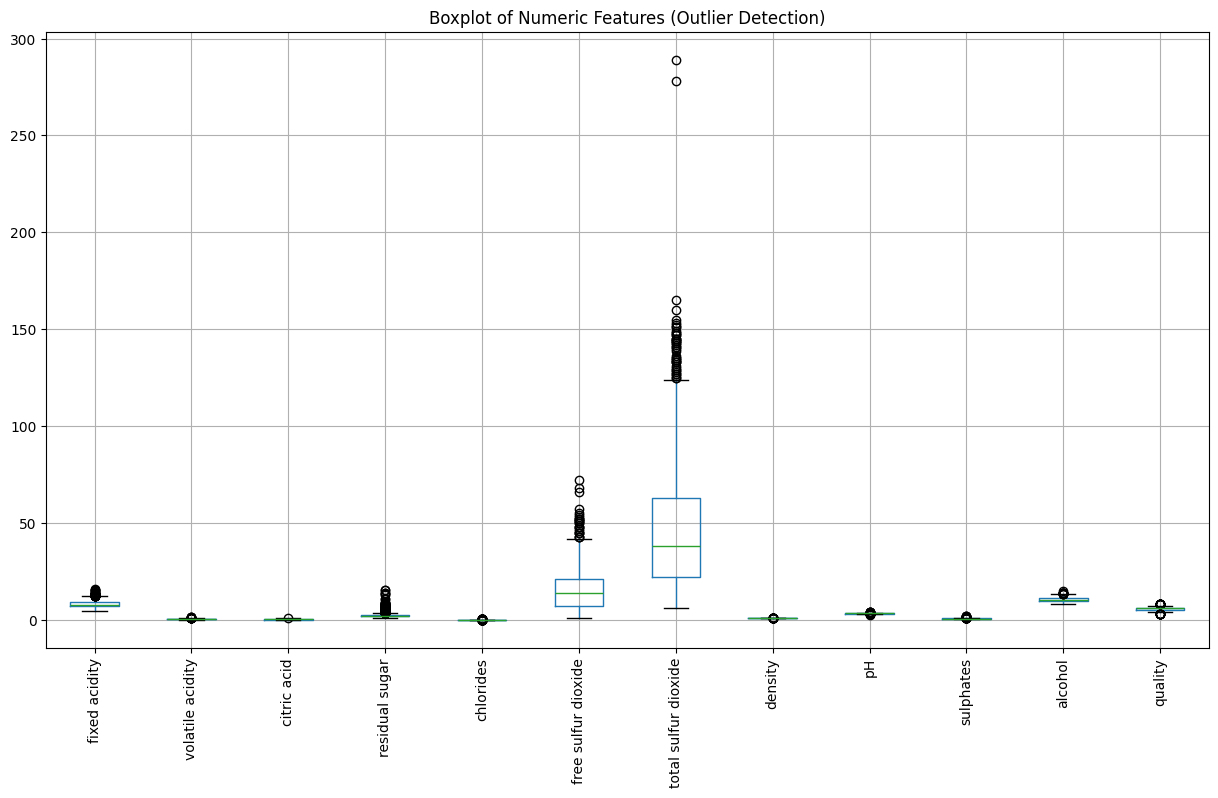

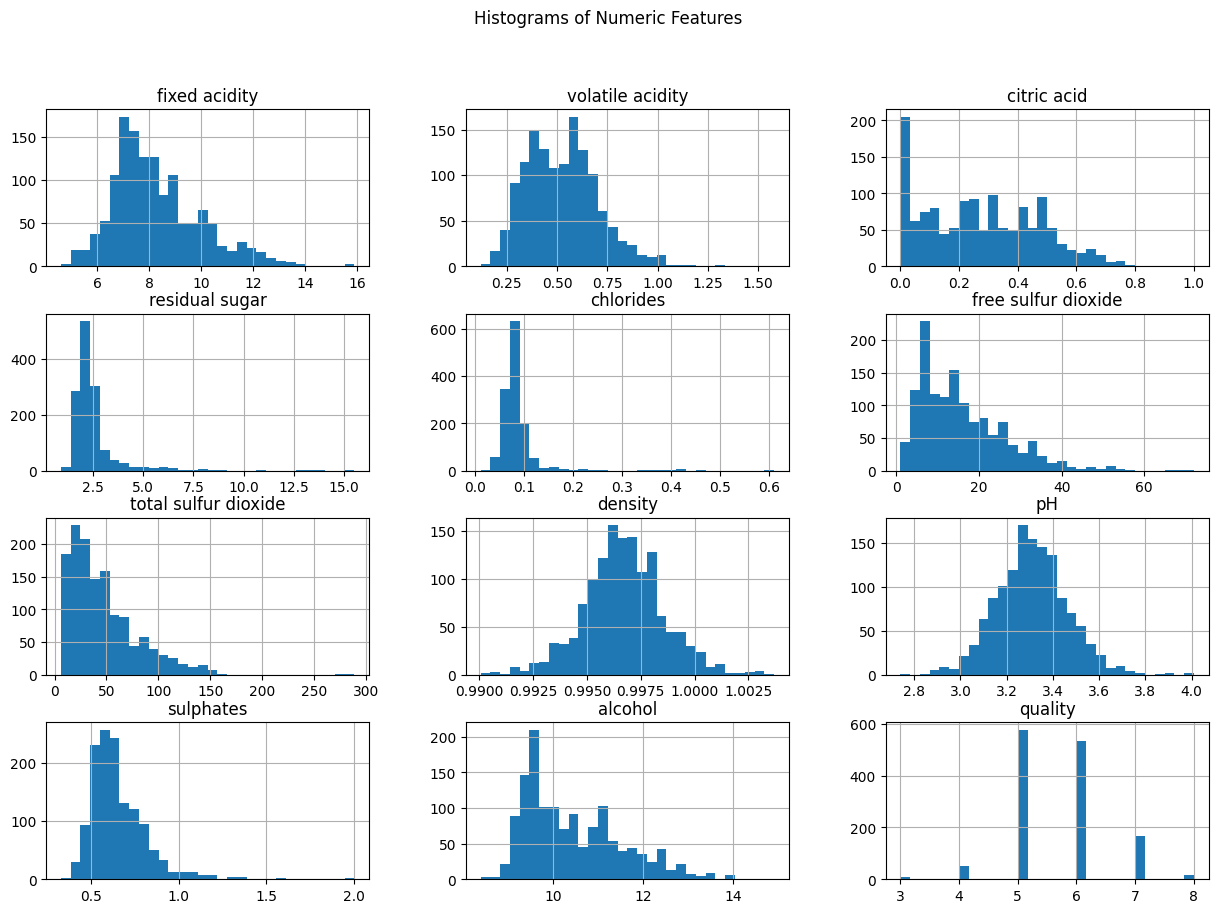

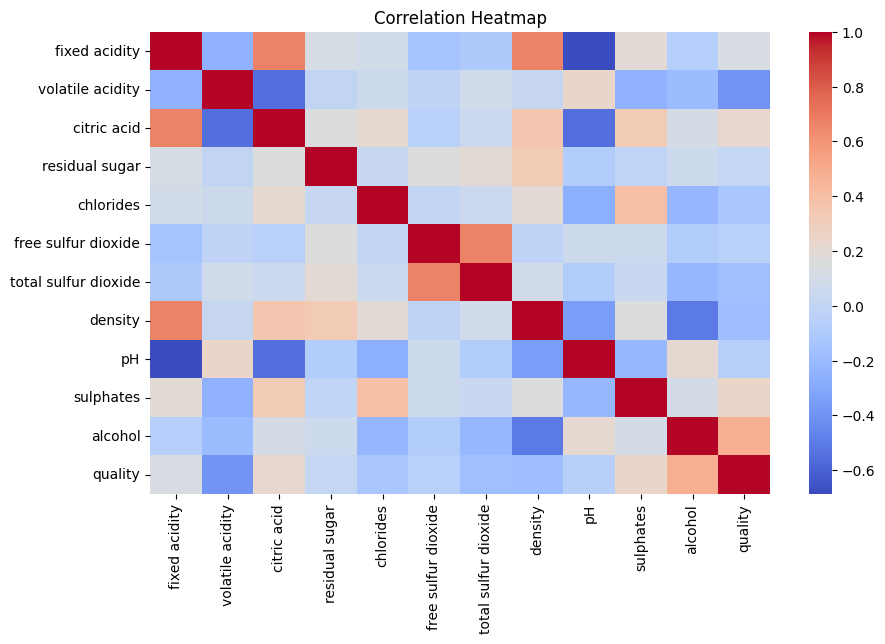

Outliers removed. Remaining rows: 1005
After removing outliers:


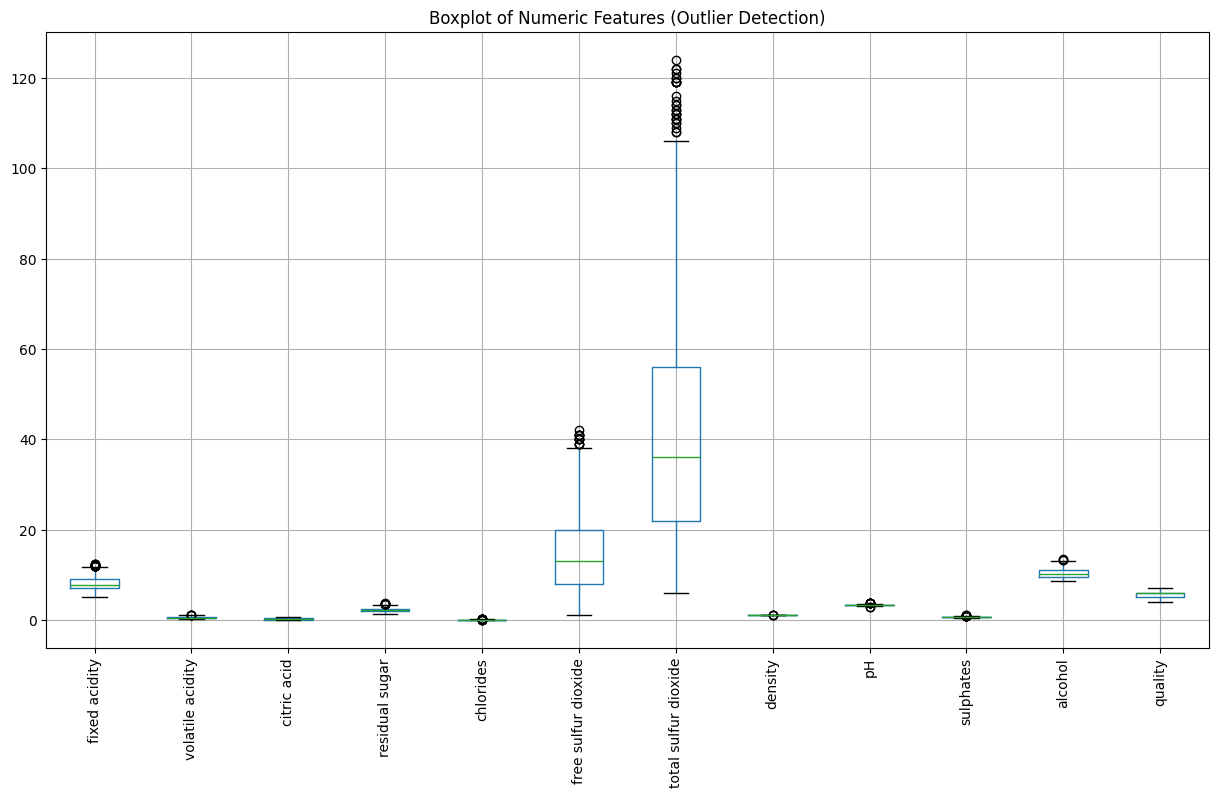

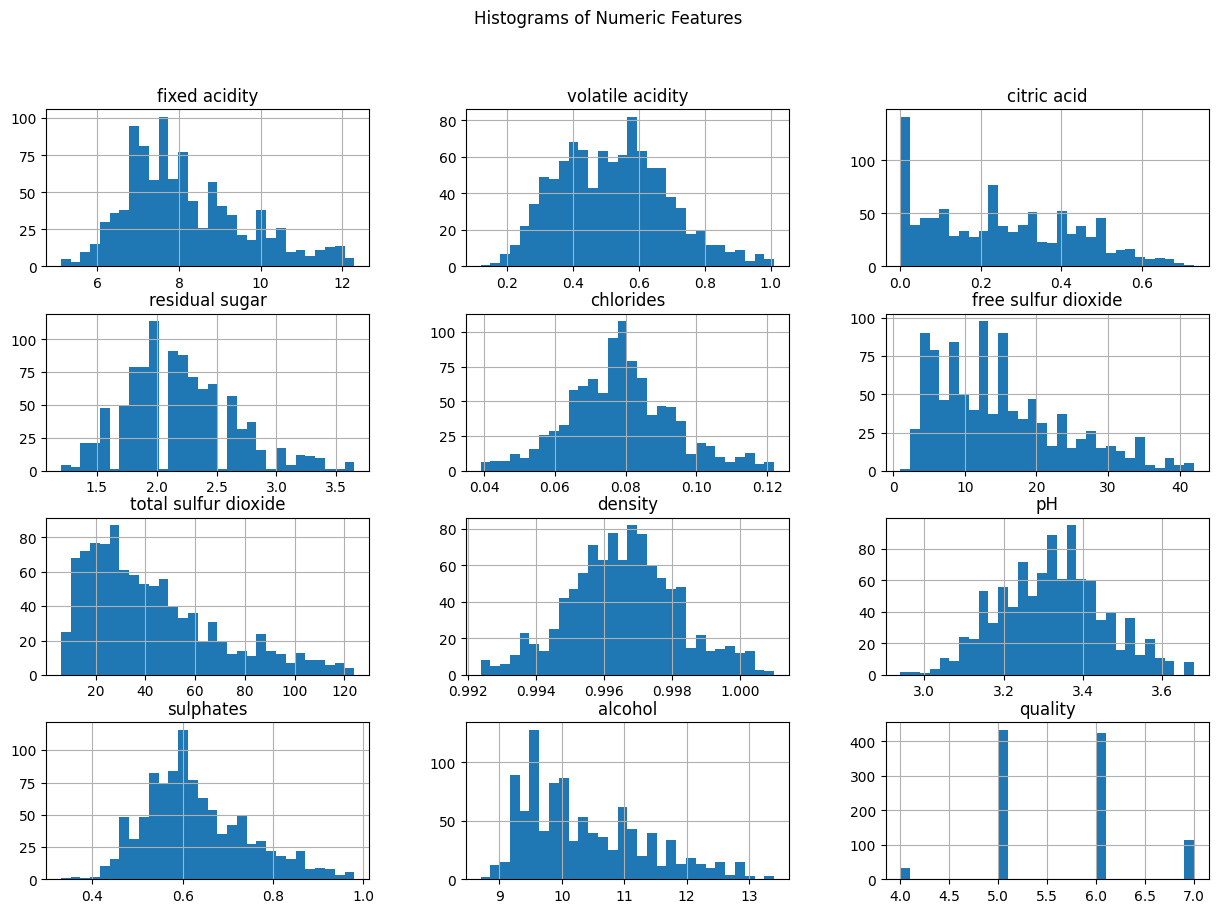

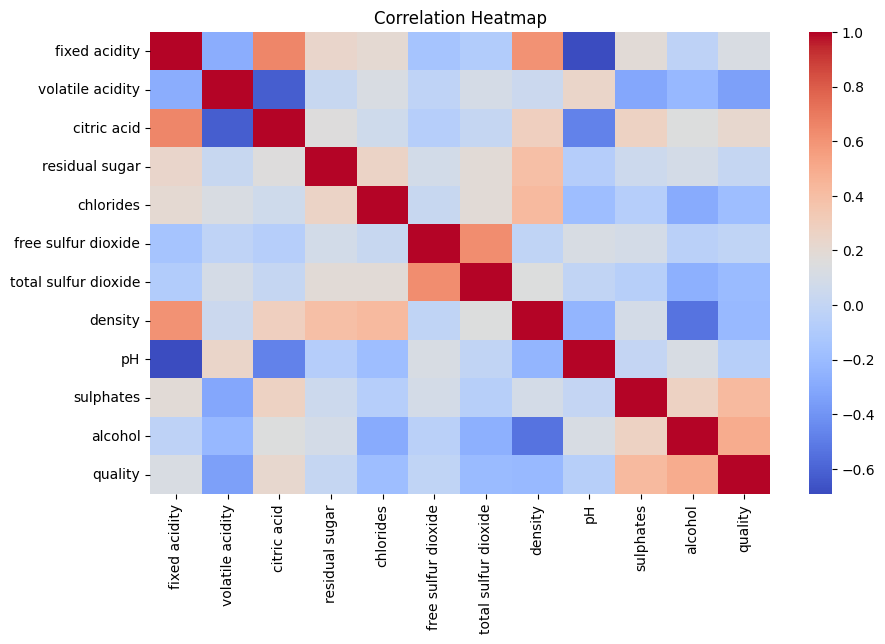

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_train.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.319444,0.651685,0.000000,0.285714,0.445783,0.243902,0.237288,0.629630,0.770270,0.353846,0.148936,0.333333
1,0.375000,0.853933,0.000000,0.571429,0.710843,0.585366,0.516949,0.513889,0.351351,0.538462,0.234043,0.333333
2,0.375000,0.719101,0.054795,0.448980,0.638554,0.341463,0.406780,0.537037,0.432432,0.492308,0.234043,0.333333
3,0.847222,0.179775,0.767123,0.285714,0.433735,0.390244,0.457627,0.652778,0.297297,0.384615,0.234043,0.666667
5,0.319444,0.606742,0.000000,0.244898,0.433735,0.292683,0.288136,0.629630,0.770270,0.353846,0.148936,0.333333


In [241]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    if(missing.sum() > 0):
        # Filter columns with missing values
        missing = missing[missing > 0].sort_values(ascending=False)

        # Plot bar chart
        plt.figure(figsize=(12,6))
        missing.plot(kind='bar')

        plt.title('Missing Values per Column')
        plt.xlabel('Features')
        plt.ylabel('Number of Missing Values')

        plt.show()
        
    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    mask = pd.Series(True, index=df.index)

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= df[col].between(lower_bound, upper_bound)

    df_cleaned = df[mask]

    print(f"Outliers removed. Remaining rows: {len(df_cleaned)}")
    return df_cleaned


def visualize_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    # 1. Boxplot
    plt.figure(figsize=(15, 8))
    df[num_cols].boxplot(rot=90)
    plt.title("Boxplot of Numeric Features (Outlier Detection)")
    plt.show()

    # 2. Histogram
    df[num_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Histograms of Numeric Features")
    plt.show()

    # 3. Heatmap correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap")
    plt.show()
    
# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(data, '/kaggle/working/cleaned_data_train.csv')

# Preview
cleaned_df.head()

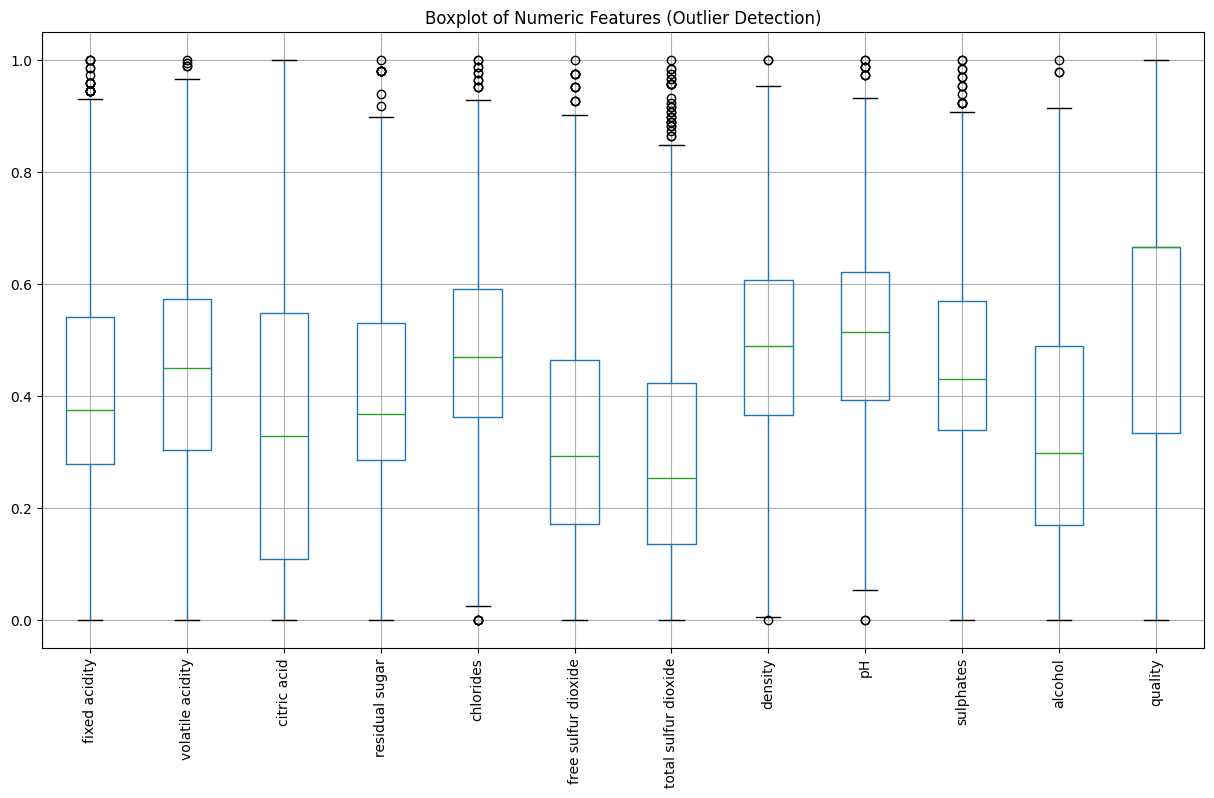

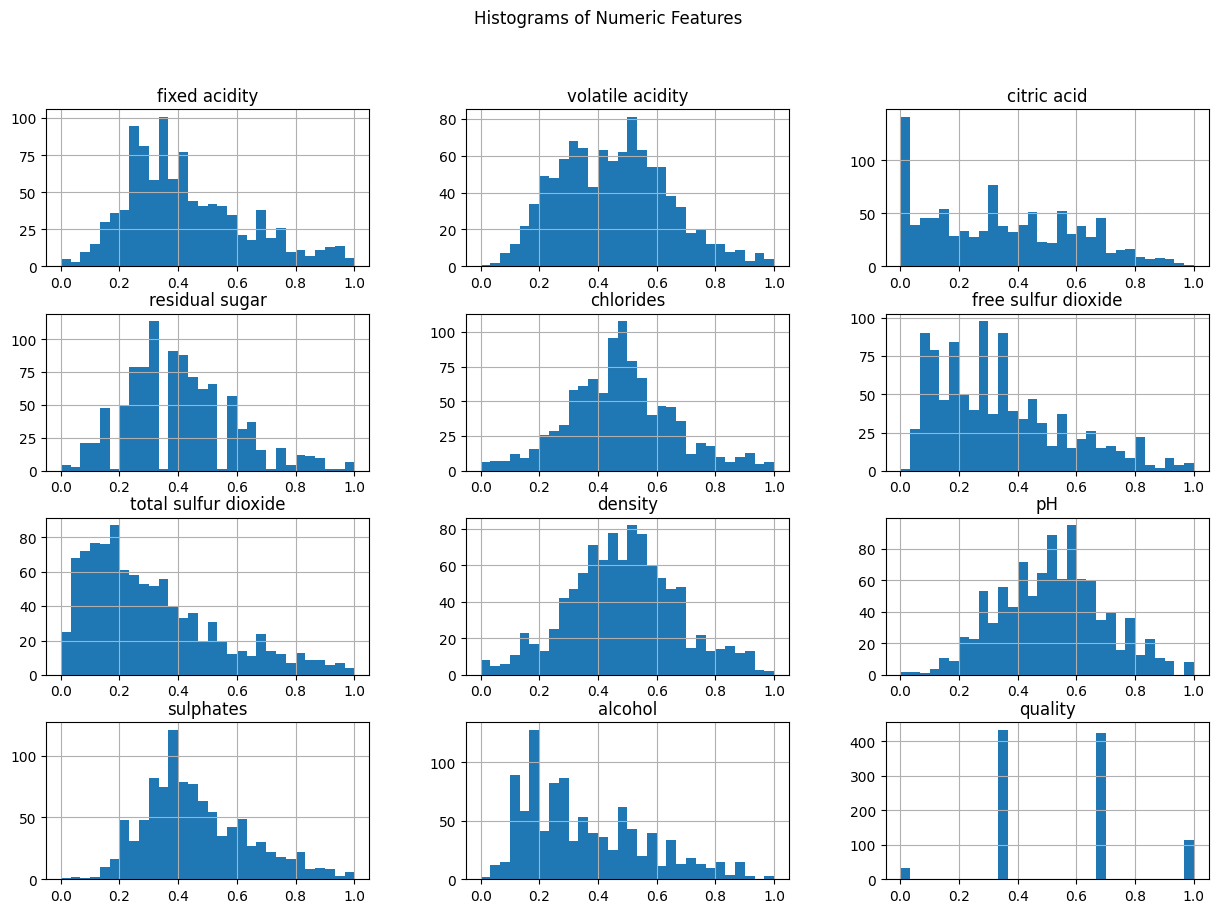

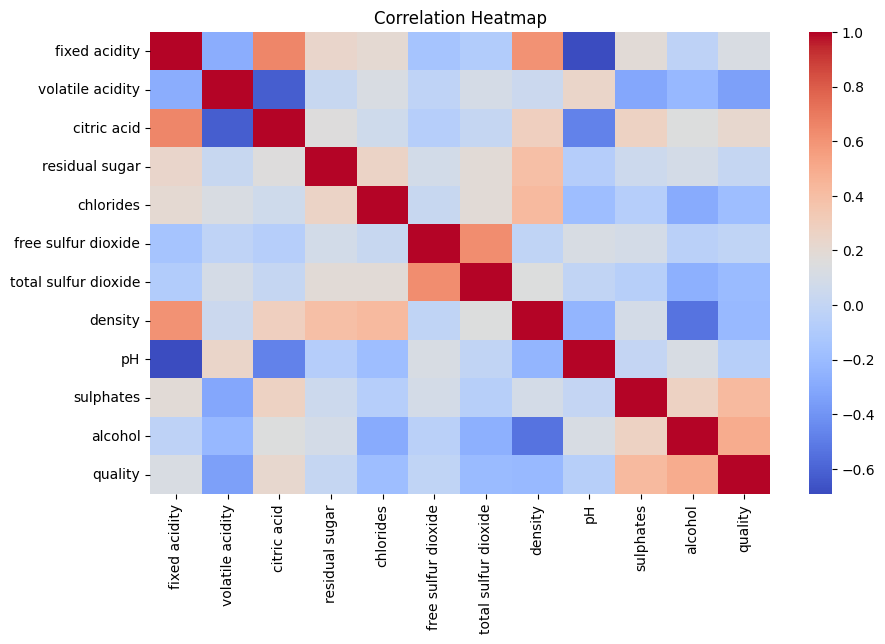

In [242]:
visualize_outliers(cleaned_df)


In [243]:
df = cleaned_df
print(df.columns)
df.columns = df.columns.str.replace(' ', '_')
Before_feature_engineering = df.columns
print(df.columns)


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [244]:
#Feature Engineering

df['total_acidity'] = df['fixed_acidity'] + df['volatile_acidity'] + df['citric_acid']

df['sulfur_ratio'] = df['free_sulfur_dioxide'] / (df['total_sulfur_dioxide'] + 1)
df['sulphate_chloride_ratio'] = df['sulphates'] / (df['chlorides'] + 1e-5)

df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['acid_alcohol_interaction'] = df['fixed_acidity'] * df['alcohol']

df['pH_level'] = pd.cut(df['pH'],
                       bins=[0, 3.0, 3.5, 4.5],
                       labels=['low', 'normal', 'high'])
df = pd.get_dummies(df, columns=['pH_level'], drop_first=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = handle_missing_values(df)

Remaining missing values: 0


/tmp/ipykernel_55/3888347958.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [245]:
def feature_selection_rf(df, target_col, top_n=10, task='regression'):
    
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    X = X.select_dtypes(include=[np.number])
    
    if task == 'regression':
        model = RandomForestRegressor(random_state=42)
    else:
        model = RandomForestClassifier(random_state=42)
    
    model.fit(X, y)
    
    importances = model.feature_importances_
    feature_names = X.columns
    
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })
    
    feat_imp = feat_imp.sort_values(by='importance', ascending=False)
    
    top_features = feat_imp.head(top_n)
    
    plt.figure(figsize=(10,6))
    plt.barh(top_features['feature'], top_features['importance'])
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Important Features")
    plt.xlabel("Importance")
    plt.show()
    
    return top_features, feat_imp

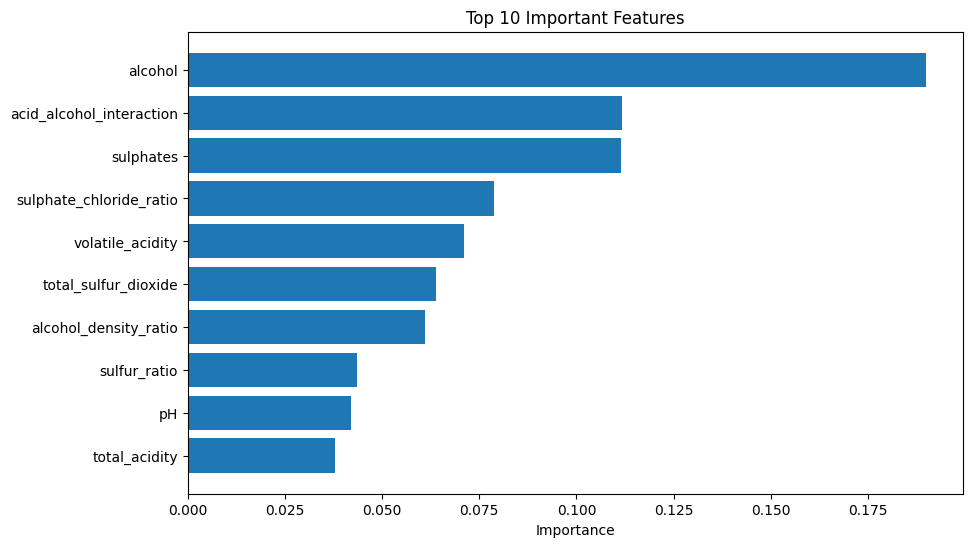

In [246]:
top_features1, all_features = feature_selection_rf(
    df,
    target_col='quality',
    top_n=10,
    task='regression'
)

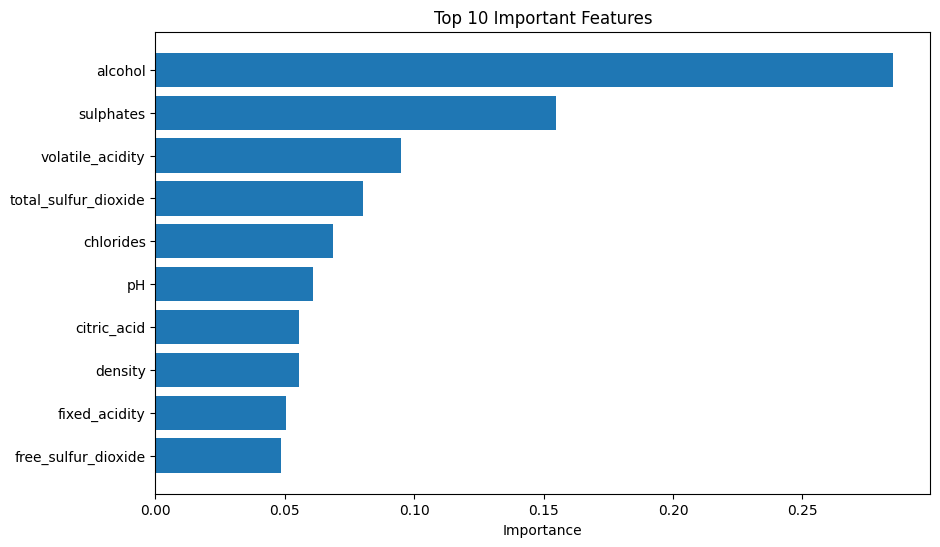

In [247]:
top_features2, all_features = feature_selection_rf(
    df[Before_feature_engineering],
    target_col='quality',
    top_n=10,
    task='regression'
)

In [248]:
def run_regression_models(X_train, X_test, y_train, y_test):
    models = {
        "Linear Regression": LinearRegression(),
        "Lasso": Lasso(),
        "Ridge": Ridge(),
        "ElasticNet": ElasticNet(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "Gradient Boosting": GradientBoostingRegressor(),
        "SVR": SVR()
    }

    results = []

    for name, model in models.items():
        
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),   
            ("scaler", StandardScaler()),                  
            ("model", model)
        ])
        
        pipe.fit(X_train, y_train)
        
        y_pred = pipe.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            "Model": name,
            "MSE": mse,
            "R2 Score": r2
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="R2 Score", ascending=False)

    plt.figure(figsize=(10,6))
    plt.barh(results_df["Model"], results_df["R2 Score"])
    plt.gca().invert_yaxis()
    plt.title("Model Comparison (R2 Score)")
    plt.xlabel("R2 Score")
    plt.show()

    return results_df

In [249]:
top_features1 = top_features1['feature'].tolist()
top_features2 = top_features2['feature'].tolist()
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'total_acidity',
       'sulfur_ratio', 'sulphate_chloride_ratio', 'alcohol_density_ratio',
       'acid_alcohol_interaction', 'pH_level_normal', 'pH_level_high'],
      dtype='object')

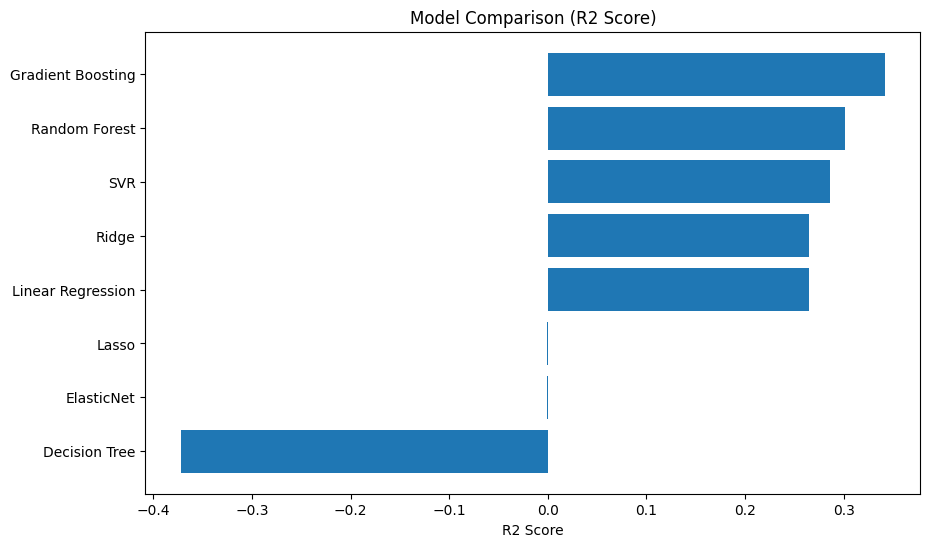

               Model       MSE  R2 Score
6  Gradient Boosting  0.069181  0.342045
5      Random Forest  0.073447  0.301478
7                SVR  0.075028  0.286436
2              Ridge  0.077276  0.265061
0  Linear Regression  0.077276  0.265056
1              Lasso  0.105185 -0.000368
3         ElasticNet  0.105185 -0.000368
4      Decision Tree  0.144279 -0.372175


In [250]:
X = df[top_features1]
X2 = df[top_features2]
y = df['quality'].astype(int)

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X.index, y, test_size=0.2, random_state=42
)

# Apply same split to both datasets
X_train = X.loc[X_train_idx]
X_test = X.loc[X_test_idx]

X_train2 = X2.loc[X_train_idx]
X_test2 = X2.loc[X_test_idx]
results = run_regression_models(X_train, X_test, y_train, y_test)
print(results)

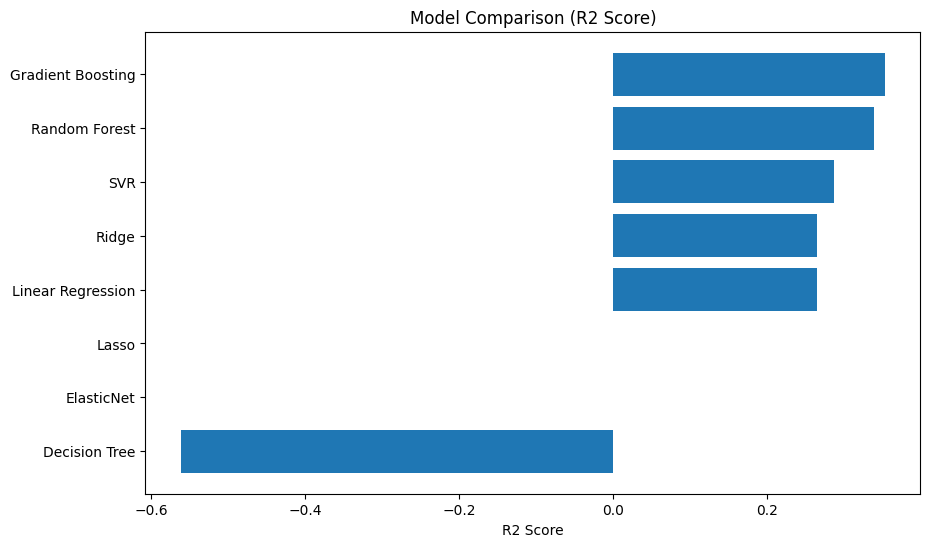

               Model       MSE  R2 Score
6  Gradient Boosting  0.068014  0.353144
5      Random Forest  0.069490  0.339108
7                SVR  0.075028  0.286436
2              Ridge  0.077276  0.265061
0  Linear Regression  0.077276  0.265056
1              Lasso  0.105185 -0.000368
3         ElasticNet  0.105185 -0.000368
4      Decision Tree  0.164179 -0.561441


In [251]:
results = run_regression_models(X_train, X_test, y_train, y_test)
print(results)

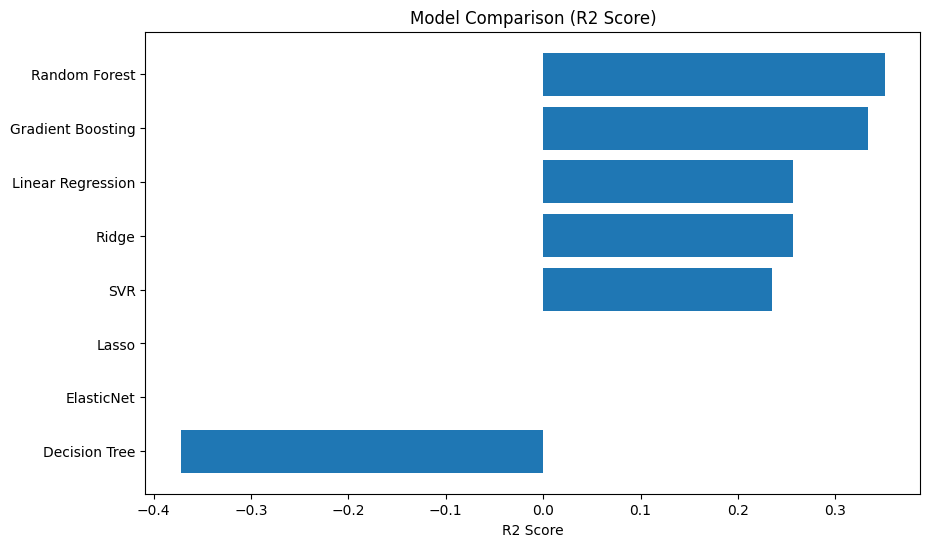

               Model       MSE  R2 Score
5      Random Forest  0.068225  0.351136
6  Gradient Boosting  0.070116  0.333158
0  Linear Regression  0.078207  0.256206
2              Ridge  0.078208  0.256197
7                SVR  0.080487  0.234525
1              Lasso  0.105185 -0.000368
3         ElasticNet  0.105185 -0.000368
4      Decision Tree  0.144279 -0.372175


In [252]:
results = run_regression_models(X_train2, X_test2, y_train, y_test)
print(results)